#--------**CAPSTONE PROJECT ON "Intro to Machine Learning Project"**-----------
###----------------------------- **By:** Tsering Dorjee **ON** ***"Summer session"/2026***-------------------------------
###-------------------------------**LaGuardia Community College**, NYC----------------------------------------

# **TITLE: *"NYS Hospital Inpatient Discharges (SPARCS De-Identified): 2024* "**

- SPARCS: The ***Statewide Planning and Research Cooperative System***
- Contains discharge level detail on patient characteristics, diagnoses, treatments, services, and charges.

**Data source:** ***health.data.ny.gov***  (Official open-data gateway run by the New York State Department of Health)

**Purpose:** The primary purpose of the NYS SPARCS dataset is to act as a centralized, all-payer data repository that tracks hospital care across New York State to monitor healthcare quality, patient outcomes, resource allocation, and medical costs. Established in 1979 by a joint initiative between the healthcare sector and government, it is managed directly by the New York State Department of Health.


**RESEARCH QUESTIONS:**

- 1. "Which specific administrative and clinical features matter most when predicting the length of stay category (e.g., short vs. extended stay) of a patient?"

- 2. "Which machine learning model most accurately predicts hospital length of stay categories after cleaning and engineering the 2024 NYS SPARCS dataset?"

     - ***A. Logical Regression (Base Model)***

       ==> PERFORMING **"One-Hot Encoding"** to create simple binary columns.
     - ***B. Random Forest (Ensemble - ***"BAGGING"*** -  Tree Model)***
       
       ==> PERFORMING **"Target Encoding"** to convert complex text features into clean numeric averages, keeping the models fast and preventing memory crashes.
     - ***C. GradientBoosting (Ensemble - ***"BOOSTING"*** -  Tree Model)***
      
        ==> PERFORMING **"Target Encoding"** to convert complex text features into clean numeric averages, keeping the models fast and preventing memory crashes.

# **1. Uploading Dataset:**

- We used a Python script to stream the 2.2+ million rows and 33 columns directly from the source bulk download API endpoint (/views/.../rows.csv) into our workspace in a single network request.

- A direct manual upload from the ***"desktop"*** or ***"GitHub"*** was not viable due to platform file size and repository push limitations on a dataset of this scale."

In [31]:
import io                                                                                 # Provides the io.StringIO or io.BytesIO utilities, which convert the downloaded raw text/bytes into a file-like stream that Python can read.
import pandas as pd
import requests                                                                           # Downloads the raw data or files from the internet via an API or URL

bulk_url = "https://health.data.ny.gov/api/v3/views/sf4k-39ay/query.csv?$limit=2500000"   # Changing /resource/ to /api/views/ drops Socrata's 1,000-row restriction, enabling all 2.2+ million rows to flow down a single network connection.

print("Starting direct bulk streaming download...")

df = pd.read_csv(bulk_url)                                                                 # Fetching the entire database directly in one single step


Starting direct bulk streaming download...


/tmp/ipykernel_2557/2725976663.py:9: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(bulk_url)                                                                 # Fetching the entire database directly in one single step


# **2.  EDA (Exploratory Data Analysis) - Initial Assessment**
After streaming the dataset, we profiled data integrity prior to transformation using two core approaches:
- **Statistical Profiling:** Evaluated data distributions, structural constraints, and numeric counts using df.info(), df.describe(), and null-value counters to establish an initial diagnostic profile across all 33 columns and 2.2M+ rows prior to data cleaning.
- **Visual Audit:** Mapped the structural distribution of missing elements across all 33 features using a **Seaborn** missing data ***"heatmap"*** with a viridis matrix color configuration."

Dataset Shape:
(2196737, 37)

Index Details:
RangeIndex(start=0, stop=2196737, step=1)

Data Types:
:id                                object
:version                           object
:created_at                        object
:updated_at                        object
health_service_area                object
hospital_county                    object
operating_certificate_number      float64
permanent_facility_id             float64
facility_name                      object
age_group                          object
zip_code                           object
gender                             object
race                               object
ethnicity                          object
length_of_stay                     object
type_of_admission                  object
patient_disposition                object
discharge_year                      int64
ccsr_diagnosis_code                object
ccsr_diagnosis_description         object
ccsr_procedure_code                object
ccsr_procedure_des

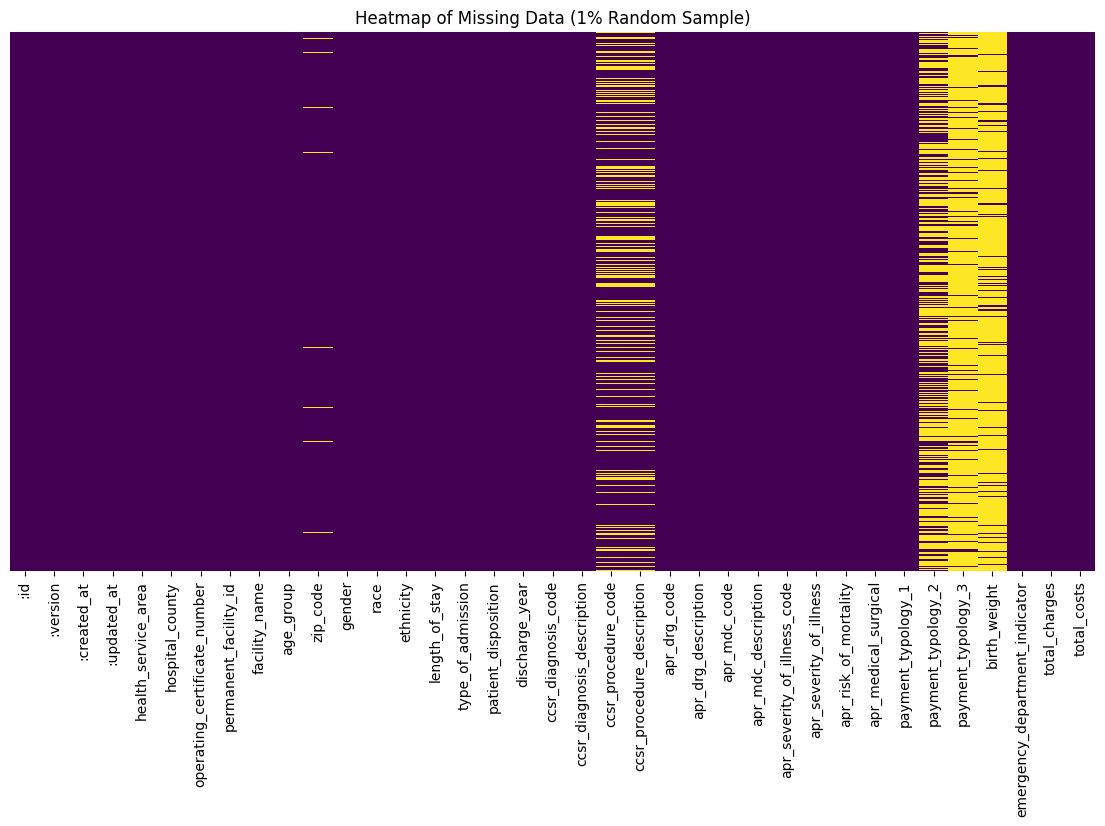

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Dataset Shape:")
print(df.shape)                                                                            # Checking Rows & Columns
print()
print("Index Details:")                                                                    # Checking row label configurations
print(df.index)
print()
print("Data Types:")                                                                       # Checking datatypes
print(df.dtypes)
print()
print(df.info())                                                                           # 1. Shows the data structure. It lists the total rows, column names, data types (e.g., int, float, object), memory usage, and the number of non-null values.
print()
print(df.describe())                                                                       # 2. Generates summary statistics. For numerical columns, it calculates counts, mean, standard deviation, minimum, maximum, and percentiles (25%, 50%, 75%).
print()
print(df.isnull().sum())                                                                   # 3. Identifies missing data. It checks every cell for missing (NaN) values and returns the total count of missing entries for each individual column.
print()

# HEATMAP TO CHECK "missing values":
'''
We are creating a fast visual audit using a random 1% sample of the 2.2 million rows to prevent kernel crash
'''
plt.figure(figsize=(14, 7))
sns.heatmap(df.sample(frac=0.01, random_state=42).isnull(), yticklabels=False, cbar=False, cmap='viridis')       # Downsampling to a representative 1% random sample for visualization. Using "df.sample(frac=0.01, random_state=42).isnull()" instead of 'df.isnull' which is for all 2.2 million rows
plt.title('Heatmap of Missing Data (1% Random Sample)')
plt.show()


# **3. Data Cleaning (Data Preprocessing): Handling Missing Values**

-  No data is dropped: We keep all rows to protect critical healthcare records and maintain data integrity.
- Missing values are filled automatically: A custom cleaning function scans the columns and handles missing data based on its type:

	- **Numerical Columns:** Missing numbers are filled with 0.
  - We skip the ***birth_weight*** column to keep adult and newborn logic separated. Using 0 instead of a changing median ensures our data values stay consistent from the first row to the 2.2+ millionth row.
  - **Categorical/Text Columns**: Missing text is filled with the word ***"Unknown"***. This preserves the data structure for the algorithms and treats missing information as its own clear category instead of creating bias.


Missing values per column after cleaning:
:id                               0
:version                          0
:created_at                       0
:updated_at                       0
health_service_area               0
hospital_county                   0
operating_certificate_number      0
permanent_facility_id             0
facility_name                     0
age_group                         0
zip_code                          0
gender                            0
race                              0
ethnicity                         0
length_of_stay                    0
type_of_admission                 0
patient_disposition               0
discharge_year                    0
ccsr_diagnosis_code               0
ccsr_diagnosis_description        0
ccsr_procedure_code               0
ccsr_procedure_description        0
apr_drg_code                      0
apr_drg_description               0
apr_mdc_code                      0
apr_mdc_description               0
apr_severity_of_illnes

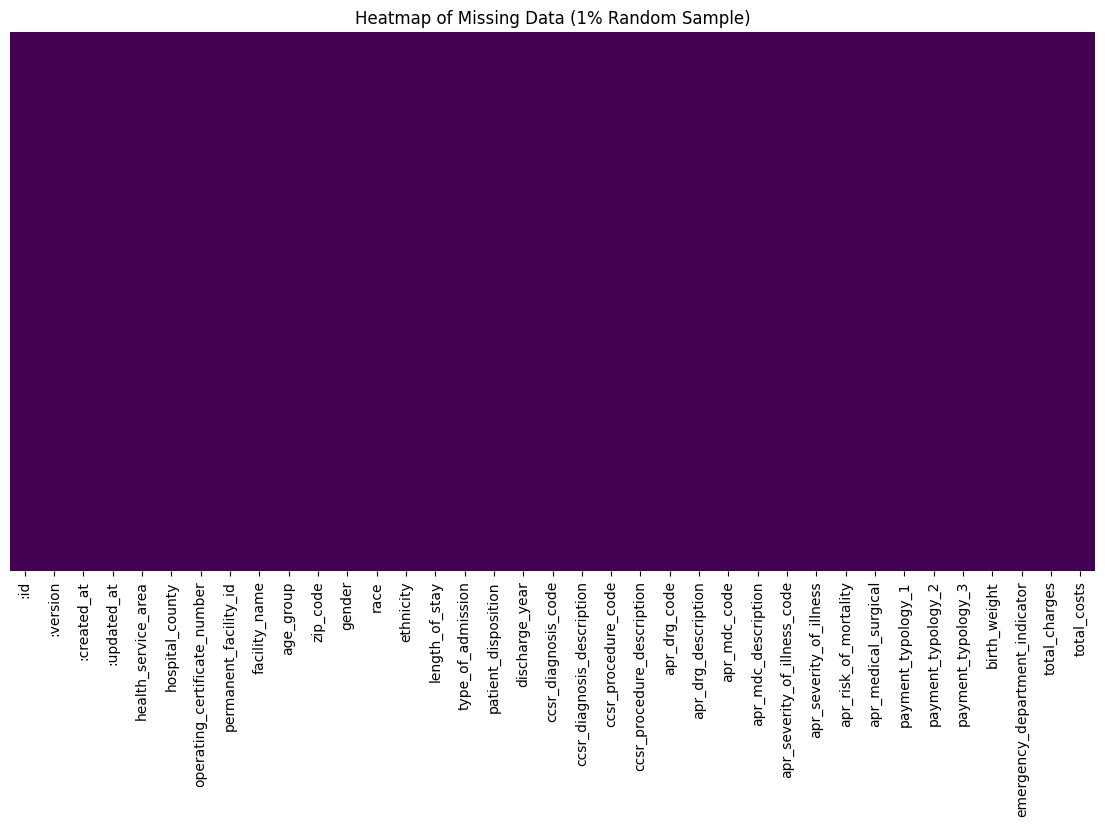

In [33]:
# DATA CLEANING FUNCTION ---

def clean_dataset(chunk_df):

    numeric_cols = chunk_df.select_dtypes(include=['number']).columns                  # 1. Fill missing numbers with 0 (excluding birth_weight to preserve newborn logic)
    numeric_cols = [col for col in numeric_cols if col != 'birth_weight']
    chunk_df[numeric_cols] = chunk_df[numeric_cols].fillna(0)

    object_cols = chunk_df.select_dtypes(include=['object']).columns                   # 2. Fill missing text/object columns with 'Unknown'
    chunk_df[object_cols] = chunk_df[object_cols].fillna('Unknown')

    return chunk_df

# Usage
df = clean_dataset(df)                                                                 # 3. Assigning clean_datset(df) back into main dataframe (df)

# Quick Verify
print("Missing values per column after cleaning:")
print(df.isnull().sum())

## HEATMAP TO CHECK "missing values" after DATA CLEANING:

# We are creating a fast visual audit using a random 1% sample of the 2.2 million rows to prevent kernel crash
plt.figure(figsize=(14, 7))
sns.heatmap(df.sample(frac=0.01, random_state=42).isnull(), yticklabels=False, cbar=False, cmap='viridis')       # Downsampling to a representative 1% random sample for visualization. Using "df.sample(frac=0.01, random_state=42).isnull()" instead of 'df.isnull' which is for all 2.2 million rows
plt.title('Heatmap of Missing Data (1% Random Sample)')
plt.show()

# 4. Dataset **SCHEMA REVIEW (baseline)** : (Reviewing Available **"Features"** & **"Target"**):
-Before isolating our predictive targets or encoding high-cardinality strings, we executed a structural feature audit by extracting and listing all active dataframe columns. Reviewing this baseline inventory allows us to explicitly map which features represent ***"Administrative intake markers"*** versus "***clinical profiles***", ensuring accurate subset selection for modeling our NYS SPARCS 2024 target."

In [34]:
import pandas as pd

all_columns = list(df.columns)                                              # 1. Retrieve all the column names from our cleaned dataset
feature_names = all_columns

print(f"Total Features Extracted: {len(feature_names)}")                    # 2.  Print the results to see your available features

print("Available Features:")
for name in feature_names:
    print(f"- {name}")

Total Features Extracted: 37
Available Features:
- :id
- :version
- :created_at
- :updated_at
- health_service_area
- hospital_county
- operating_certificate_number
- permanent_facility_id
- facility_name
- age_group
- zip_code
- gender
- race
- ethnicity
- length_of_stay
- type_of_admission
- patient_disposition
- discharge_year
- ccsr_diagnosis_code
- ccsr_diagnosis_description
- ccsr_procedure_code
- ccsr_procedure_description
- apr_drg_code
- apr_drg_description
- apr_mdc_code
- apr_mdc_description
- apr_severity_of_illness_code
- apr_severity_of_illness
- apr_risk_of_mortality
- apr_medical_surgical
- payment_typology_1
- payment_typology_2
- payment_typology_3
- birth_weight
- emergency_department_indicator
- total_charges
- total_costs


# **5. Target Distribution Analysis & Class Imbalance Check:**
##-  This analysis audits the internal distribution of our target variable, ***'length_of_stay'***, before training any machine learning models.
- **Detect Class Imbalance:** Checks if a single category dominates over 65% of the data. If it does, models will blindly predict that majority class to cheat for a high accuracy score.
- **Evaluate Target Structure:** The output shows ***'length_of_stay'*** is split into individual days with tiny fractions (0.01%). This confirms we must group these days into broader categories to match our research questions.

In [35]:
import pandas as pd
total_patients = len(df)                                                                                          # 1. Calculating class percentages
class_counts = df['length_of_stay'].value_counts()

print("CHECKING DATA-SIDE BIAS RISK:")
print(f"Total Rows Checked: {total_patients:,}\n")

for category, count in class_counts.items():
    percentage = (count / total_patients) * 100
    print(f" Category '{category}': {count:,} records ({percentage:.2f}%)")


print("\n BIAS EVALUATION:")                                                                                       # 2. Flagging the structural risk
majority_percentage = (class_counts.iloc[0] / total_patients) * 100

if majority_percentage > 65:
    print(f" HIGH BIAS RISK! The majority class makes up {majority_percentage:.2f}% of your data.")
    print("ML models will naturally favor this group to cheat for accuracy.")

else:
    print(" LOW BIAS RISK! the target variable 'length_of_stay' classes are evenly distributed.")



CHECKING DATA-SIDE BIAS RISK:
Total Rows Checked: 2,196,737

 Category '2': 464,690 records (21.15%)
 Category '1': 392,917 records (17.89%)
 Category '3': 334,224 records (15.21%)
 Category '4': 214,203 records (9.75%)
 Category '5': 149,406 records (6.80%)
 Category '6': 111,585 records (5.08%)
 Category '7': 88,766 records (4.04%)
 Category '8': 67,129 records (3.06%)
 Category '9': 51,272 records (2.33%)
 Category '10': 41,454 records (1.89%)
 Category '11': 34,623 records (1.58%)
 Category '12': 28,348 records (1.29%)
 Category '13': 25,854 records (1.18%)
 Category '14': 23,822 records (1.08%)
 Category '15': 19,134 records (0.87%)
 Category '16': 15,089 records (0.69%)
 Category '17': 12,608 records (0.57%)
 Category '18': 10,837 records (0.49%)
 Category '19': 9,500 records (0.43%)
 Category '21': 8,803 records (0.40%)
 Category '20': 8,771 records (0.40%)
 Category '22': 6,902 records (0.31%)
 Category '28': 5,977 records (0.27%)
 Category '23': 5,809 records (0.26%)
 Category

# **6. Categorical Cardinality Audit (High Variance Risk Assessment)**:
## -**(Variance & Cardinality audit tool)**
**• Purpose:**
- To scan all categorical text columns and identify features with more than 50 unique labels before encoding.

**• Why it is required for ML:**
- High-cardinality text columns cause feature explosion during ***One-Hot Encoding*** (leading to RAM crashes) and
- It forcse tree-based models ***(Random Forest/Gradient Boosting)*** to overfit.
- Stop algorithms from memorizing specific text values instead of learning generalized clinical patterns.


In [36]:
counts = df.drop(columns=['length_of_stay'], errors='ignore').select_dtypes(include=['object', 'category']).nunique()                                    # 1. Drops target variable 'length_of_stay'
                                                                                                                                                         #    Isolates the text-based variables (object and category)
                                                                                                                                                         #    Counts unique values (nunique()) in each column.


print("VARIANCE AUDIT & RISK EVALUATION:")
for col, val in counts.items():                                                                                                                          # 2. Loops through every column and prints its unique value count
    print(f"• '{col}': {val:,} values" + ("  HIGH RISK!" if val > 50 else ""))                                                                           #     Flags "HIGH RISK", If any feature contains more than 50 unique options


if counts.max() > 50:                                                                                                                                    # 3. iF > 50 unique options, it flags a "global High Variance Risk" & RECOMMENDS "TARGET ENCODING"
    print("\n HIGH VARIANCE RISK! Text features have massive variations.\n- Random Forest/Gradient Boosting will overfit. Use Target Encoding!")
else:
    print("\n LOW VARIANCE RISK! Text feature options are compact and stable.")


VARIANCE AUDIT & RISK EVALUATION:
• ':id': 2,196,737 values  HIGH RISK!
• ':version': 2,196,737 values  HIGH RISK!
• ':created_at': 1 values
• ':updated_at': 1 values
• 'health_service_area': 9 values
• 'hospital_county': 58 values  HIGH RISK!
• 'facility_name': 203 values  HIGH RISK!
• 'age_group': 5 values
• 'zip_code': 51 values  HIGH RISK!
• 'gender': 3 values
• 'race': 4 values
• 'ethnicity': 4 values
• 'type_of_admission': 6 values
• 'patient_disposition': 19 values
• 'ccsr_diagnosis_code': 478 values  HIGH RISK!
• 'ccsr_diagnosis_description': 478 values  HIGH RISK!
• 'ccsr_procedure_code': 321 values  HIGH RISK!
• 'ccsr_procedure_description': 321 values  HIGH RISK!
• 'apr_drg_description': 336 values  HIGH RISK!
• 'apr_mdc_description': 26 values
• 'apr_severity_of_illness': 5 values
• 'apr_risk_of_mortality': 5 values
• 'apr_medical_surgical': 3 values
• 'payment_typology_1': 10 values
• 'payment_typology_2': 10 values
• 'payment_typology_3': 10 values
• 'birth_weight': 122 v

# **7. FEATURE ENGINEERING FOR ML**



## **A. Target Variable** ***("length_of_stay")*** Extraction & Binarization
• Converting the continuous ***length_of_stay*** column into a ***binary target (PLoS***) for classification

• Calculates the ***75th percentile threshold*** to isolate the top ***25% longest stays,*** avoiding average-bloating outliers.

• Replaces the text tracking cap "120+" with a numeric value of 120 to allow math operations.

• Flags **long_stays** as **1** and ***short_stays*** as 0, outputting the final class distribution balance.
(Checks every single row to see if the patient's stay is greater than or equal to your 75th percentile threshold (6.0 days).)

**NOTE:**
- We stick with 6 days because that is the exact 75th percentile calculated directly from your 2024 SPARCS datase

In [37]:
import numpy as np
import pandas as pd

target_col = "length_of_stay"                                                                           # 1. Cleaning the "target column" and handle the text '120+' cap
df[target_col] = df[target_col].astype(str).str.strip().str.replace('120+', '120', regex=False)
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])

plos_threshold = np.percentile(df[target_col], 75)                                                     # 2.  Calculated the 75th percentile to statistically define a Normal Stay (< 6 days) versus a Prolonged Stay (≥ 6 days).
print(f"Calculated 75th Percentile Threshold: {plos_threshold} days")

df['PLoS'] = (df[target_col] >= plos_threshold).astype(int)                                            # 3. Created the binary target variable (1 = Long Stay, 0 = Normal Stay)

print("\nTarget Class Distribution Breakdown:")                                                        # 4. Printing the final results and percentage breakdown
print(df['PLoS'].value_counts())
print("\nTarget Percentage Breakdown (%):")
print(df['PLoS'].value_counts(normalize=True) * 100)


Calculated 75th Percentile Threshold: 6.0 days

Target Class Distribution Breakdown:
PLoS
0    1555440
1     641297
Name: count, dtype: int64

Target Percentage Breakdown (%):
PLoS
0    70.806838
1    29.193162
Name: proportion, dtype: float64


## **B. Dropping Redundant Features & Eliminating Leakage**
• **The Goal**: Permanently purges columns that cause look-ahead bias or text redundancy, isolating a clean model matrix.

• **Leakage Avoidance**: Drops variables like total_costs, total_charges and patient_disposition because they are finalized at discharge, keeping only what is known at intake.

• **Redundancy Reduction**: Drops long text descriptions (like apr_drg_description) and keeps the compact _code equivalents to save memory and avoid multi-collinearity.

• **The Footprint**: Automatically confirms a final modeling matrix containing 9 clean administrative features, 8 clinical features, and the 1 target vector (PLoS).

In [38]:
columns_to_drop = [
    "hospital_county", "patient_disposition", "operating_certificate_number",
    "permanent_facility_id", "facility_name", "discharge_year",
    "total_charges", "total_costs", "length_of_stay",
    "payment_typology_2", "payment_typology_3",
    "apr_severity_of_illness", "ccsr_diagnosis_description",
    "ccsr_procedure_description", "apr_drg_description", "apr_mdc_description",
    ":id", ":version", ":created_at", ":updated_at"
]

df.drop(columns=columns_to_drop, errors="ignore", inplace=True)                                         # 1. Drop post-discharge features to eliminate look-ahead bias

admin_lookup = ["health_service_area", "age_group", "zip_code", "gender", "race", "ethnicity", "type_of_admission", "payment_typology_1", "emergency_department_indicator"]
clinical_lookup = ["apr_drg_code", "ccsr_procedure_code", "ccsr_diagnosis_code", "apr_risk_of_mortality", "apr_mdc_code", "apr_medical_surgical", "birth_weight", "is_newborn", "apr_severity_of_illness_code"]

remaining_admin = [c for c in df.columns if c in admin_lookup]                                          # 2. Filter and isolate active administrative features
remaining_clinical = [c for c in df.columns if c in clinical_lookup]                                    # 3. Filter and isolate active clinical predictors
other_cols = [c for c in df.columns if c not in remaining_admin and c not in remaining_clinical]        # 4. Identify remaining tracking variables (Target Variable)

print(f"TOTAL ACTIVE FEATURES IN DATAFRAME: {df.shape[1]}")                                             # 5. Print final modeling feature count verification matrix
print()
print(f"\n Administrative Features Left ({len(remaining_admin)}):\n{remaining_admin}")                # 6. Output clear breakdown of administrative features
print(f"\n Clinical Features Left ({len(remaining_clinical)}):\n{remaining_clinical}")                # 7. Output clear breakdown of clinical features
print(f"\n Target / Other Variables Left ({len(other_cols)}):\n{other_cols}")                         # 8. Confirm target column position and safety


TOTAL ACTIVE FEATURES IN DATAFRAME: 18


 Administrative Features Left (9):
['health_service_area', 'age_group', 'zip_code', 'gender', 'race', 'ethnicity', 'type_of_admission', 'payment_typology_1', 'emergency_department_indicator']

 Clinical Features Left (8):
['ccsr_diagnosis_code', 'ccsr_procedure_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_of_illness_code', 'apr_risk_of_mortality', 'apr_medical_surgical', 'birth_weight']

 Target / Other Variables Left (1):
['PLoS']


## **C. Downsampling for** ***"Crash Prevention"***

- We scale the dataset down to 100,000 rows to prevent memory crashes.
- Stratifying by `age_group` keeps the exact same mix of babies, adults, and elderly patients as the full dataset.
- This protects our newborn data (`birth_weight`) and keeps hospital stay patterns realistic.
- Stratification was locked to the age_group feature to perfectly preserve demographic distributions, clinical trends, and newborn-specific indicators (like birth weight) without introducing sampling bias.

In [39]:
import gc
from sklearn.model_selection import train_test_split

#  Downsampling the remaining columns (keeping features + target together)
target_size = 100000                                                                                      # Sets a target cap of 100,000 rows

if len(df) > target_size:
    print(f"Downsampling to {target_size:,} rows stratified by 'age_group'...")
    df, _ = train_test_split(df, train_size=target_size, stratify=df['age_group'], random_state=42)
    gc.collect()
    print(f"Success! Current Dataframe Shape: {df.shape}")
print(f"Success! Current Dataframe Shape: {df.shape}")

Downsampling to 100,000 rows stratified by 'age_group'...
Success! Current Dataframe Shape: (100000, 18)
Success! Current Dataframe Shape: (100000, 18)


#**D. Handling Missing Values (birth_weight)**
- Even though we fixed with data cleaning function to stop it from breaking things, ***"birth_weight"*** still contains thousands of missing (NaN) values right now. If we try to feed raw NaN values directly into a ML models later, the model training code may crash.

In [40]:

birth_weight_numeric = pd.to_numeric(df['birth_weight'], errors='coerce')                   # 1. Force convert birth_weight to numbers, turning 'Unknown' strings back into NaN
df['is_newborn'] = birth_weight_numeric.notna().astype('int8')                              # 2. Create the binary newborn flag while the true NaN values are restored
df['birth_weight'] = birth_weight_numeric.fillna(0).astype('float32')                       # 3. Safely fill those newborn missing weights with 0 and convert to float32

print("Missing birth weights cleanly resolved!")
print(df[['birth_weight', 'is_newborn']].head(10))                                          # 4. Filters DataFrame down to look only at 'birth_weight' & 'is_newborn' side-by-side to cross-check their relationship.


Missing birth weights cleanly resolved!
         birth_weight  is_newborn
1144393           0.0           0
1323086           0.0           0
1675643           0.0           0
480657            0.0           0
533559            0.0           0
2088697           0.0           0
1347435           0.0           0
1519274           0.0           0
1877320           0.0           0
1659999        3700.0           1


# **7. MODEL TRAINING & PERFORMANCE EVALUATION:-**
- ### ***I) Baseline Model -->***   Logistic Regression
- ### ***II) Ensemble Tree Model -->***  Random Forest Classifier
- ### ***III) Boosting Tree Model -->***   Gradient Boosting Classifier






##I) **Baseline Model**--> Logistic Regression
- **Purpose:** Serves as our linear baseline to establish a benchmark performance.
- **Key Requirements:** Requires feature scaling (`StandardScaler`) to perform optimally.

**NOTE:**
-  Out of **"TOTAL 18 FEATURES"** in our dataset, **4** ***features*** are handled manually—with:
- ***'apr_risk_of_mortality'*** and ***'apr_severity_of_illness_code'*** undergoing manual ordinal encoding to preserve their natural hierarchical rank
- ***'birth_weight'*** and ***'is_newborn'*** remain untouched as they are already formatted as clean numeric inputs.

- **Remaining** ***'14 nominal features':***  possess no natural order or numerical relationship, SO, they require explicit **"ONE-HOT-ENCODING"** to transform their distinct categorical labels into machine-readable binary columns.




## **A. PERFORMING:**
- 1.***"Ordinal Mapping: MANUAL ENCODING"***,
- 2.***"ONE-HOT-ENCODING"***,
- 3.***"TRAIN-TEST SPLIT"***,
- 4.***"EXCLUDING TEXT & DATA SCALING"***,
- 5.***BASE MODEL TRAING- "Logical Regression"***

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ==========================================================================================================================
# STEP 1: Performing "manual encoding" (ORDINAL MAPPING) for 4 features  AND "one-hot-encoding for remaining 14 features"
# ==========================================================================================================================

# 1. MAPPING categorical text column "apr_severity_of_illness". its text labels MAPPED to ordered numbers (Ordinal Encoding).
severity_map = {

    'Minor': 1, 'Moderate': 2, 'Major': 3, 'Extreme': 4, 'Undetermined': 1
}

# 2. MAPPING categorical text column 'Risk of Mortality' BY applying (ordinal encoding)
if 'apr_risk_of_mortality' in df.columns:
    df['apr_risk_of_mortality'] = df['apr_risk_of_mortality'].fillna('Minor').map(severity_map).fillna(1).astype('int8')

# 3. Numeric Type Standardization: Severity of Illness Code - Ensuring the illness code column is formatted as a clean integer scale
if 'apr_severity_of_illness_code' in df.columns:
    df['apr_severity_of_illness_code'] = pd.to_numeric(df['apr_severity_of_illness_code'], errors='coerce').fillna(1).astype('int8')

# 4. Nominal Feature Identification for One-Hot Encoding
nominal_cols = [
    'health_service_area', 'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'type_of_admission', 'payment_typology_1', 'emergency_department_indicator',
    'ccsr_diagnosis_code', 'ccsr_procedure_code', 'apr_drg_code',
    'apr_mdc_code', 'apr_medical_surgical'
]

# 5. Converting nominal 14 features to text strings first to prevent encoding bugs
for col in nominal_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).fillna("Unknown")

# 6. Then, Applying One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=[c for c in nominal_cols if c in df.columns], drop_first=True)

print(" Features encoded into clean numeric formats!")
print(f"New Dataframe Shape: {df_encoded.shape}\n")


# =====================================================================
# STEP 2: TRAIN-TEST SPLIT
# =====================================================================

# 1. Pointing directly to df_encoded to grab all features (separating Targets)
X = df_encoded.drop(columns=['PLoS', 'length_of_stay', 'LOS_numeric'], errors='ignore')                 # Grabs fully encoded features (df_encoded) & drops target (PLoS, length_of_stay, LOS_numeric) & assigned into "X". This ensures the model only sees 'FEATURES' not 'TARGET'.
y = df_encoded['PLoS']                                                                                  # Isolates target variable (PLoS) so the model knows exactly what it is trying to predict & ASSIGN it into "y"

# 2. Performing the official 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("--- MODELING MATRIX SPLIT COMPLETE ---")
print(f"X_train Shape: {X_train.shape} (All features are now loaded!)")
print(f"X_test Shape: {X_test.shape}\n")


# =====================================================================
# STEP 3: EXCLUDing TEXT & DATA SCALING
# =====================================================================

# 1. Excluding raw text fields to keep numbers and encoded switches
X_train_clean = X_train.select_dtypes(exclude=['object', 'category'])
X_test_clean = X_test.select_dtypes(exclude=['object', 'category'])

print(" Standard Scaling all features for modeling...")
scaler = StandardScaler()

# 2. Fitting on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train_clean)                        # 80% is assigned into 'X_train_scaled'
X_test_scaled = scaler.transform(X_test_clean)                              # 20% is hidden away in 'X_train_scaled' FOR "TESTING"

print(" Scaling Complete!")
print(f"Scaled Train Matrix Shape: {X_train_scaled.shape}")
print(f"Scaled Test Matrix Shape: {X_test_scaled.shape}\n")


# =====================================================================
# STEP 4: BASE MODEL - logical regression - MODEL TRAINING
# =====================================================================

print("Training Base Model: Logistic Regression Classifier...")

# Training the baseline 'LOGICAL REGRESSION classifier'
base_model = LogisticRegression(solver='lbfgs', max_iter=500, random_state=42, n_jobs=-1)
base_model.fit(X_train_scaled, y_train)

# Generate category predictions and continuous risk probabilities
lr_preds = base_model.predict(X_test_scaled)
lr_probs = base_model.predict_proba(X_test_scaled)[:, 1]


 Features encoded into clean numeric formats!
New Dataframe Shape: (100000, 1201)

--- MODELING MATRIX SPLIT COMPLETE ---
X_train Shape: (80000, 1200) (All features are now loaded!)
X_test Shape: (20000, 1200)

 Standard Scaling all features for modeling...
 Scaling Complete!
Scaled Train Matrix Shape: (80000, 1200)
Scaled Test Matrix Shape: (20000, 1200)

Training Base Model: Logistic Regression Classifier...


## **B. ***Classification Report*** - "LOGICAL REGRESSION:"**
-

In [42]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

lr_preds = base_model.predict(X_test_scaled)                                                                  # Generating Classification Report
lr_probs = base_model.predict_proba(X_test_scaled)[:, 1]

print("--- BASE MODEL: LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f} ({accuracy_score(y_test, lr_preds)*100:.2f}%)")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Normal Stay', 'Prolonged Stay']))
print("\n")


--- BASE MODEL: LOGISTIC REGRESSION RESULTS ---
Accuracy: 0.8061 (80.61%)
ROC-AUC Score: 0.8599

Classification Report:
                precision    recall  f1-score   support

   Normal Stay       0.83      0.91      0.87     14144
Prolonged Stay       0.71      0.56      0.63      5856

      accuracy                           0.81     20000
     macro avg       0.77      0.74      0.75     20000
  weighted avg       0.80      0.81      0.80     20000





## **C. ***Confusion Matrix*** - "LOGICAL REGRESSION:"**

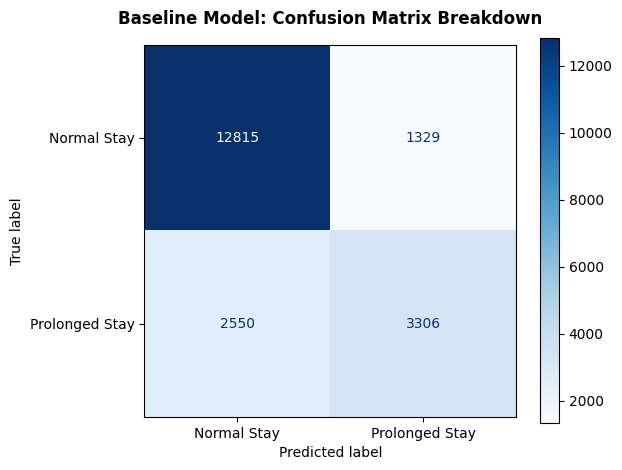

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_preds)                                                          # 1. Calculating the raw counts of True/False Positives and Negatives   # (Using baseline logistic regression predictions 'lr_preds')

disp = ConfusionMatrixDisplay(                                                                   # 2. Setting up the visual plot with labels matching your classification report
    confusion_matrix=cm,
    display_labels=['Normal Stay', 'Prolonged Stay']
)

fig, ax = plt.subplots(figsize=(6, 5))                                                           # 3. Plotting the matrix using a clean healthcare blue theme
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Baseline Model: Confusion Matrix Breakdown", pad=15, fontsize=12, fontweight='bold')
plt.grid(False) # Turn off background grid lines for a clean presentation look
plt.show()


## **D. ***Top 10 Features:***  - "LOGICAL REGRESSION:"**

Number of feature names found: 1200
Number of coefficients in model: 1200


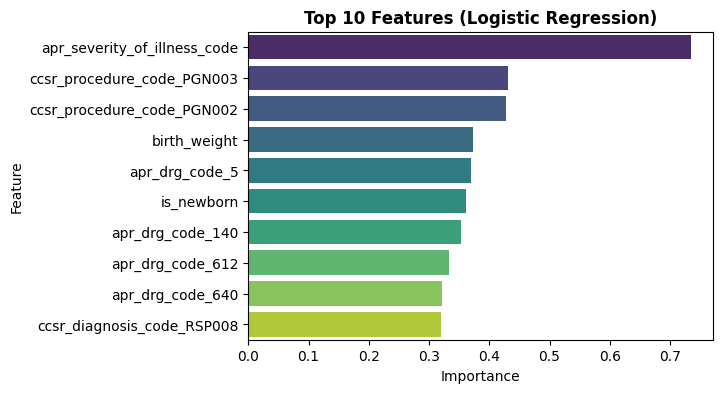

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cols_to_drop = ['PLoS', 'length_of_stay', 'LOS_numeric']                                                            # 1. Getting the columns that were actually excluded or included
feature_names = [col for col in df_encoded.columns if col not in cols_to_drop]

coefficients = base_model.coef_[0]                                                                                  # 2. Extracting coefficients

# Diagnostic Validation Check
print(f"Number of feature names found: {len(feature_names)}")                                                       # 3. Printing "Number of Features" found in the model
print(f"Number of coefficients in model: {len(coefficients)}")                                                      # 4. Printing "Number of coefficients" in the model


if len(feature_names) != len(coefficients):                                                                         # 5. Aligning them safely if they don't match
    print(" Lengths do not match! Automatically creating generic labels to keep our notebook running...")

    feature_names = [f"Feature {i}" for i in range(len(coefficients))]                                              # 6. Using generic names matching the model size if there's a structural mismatch

importance_df = pd.DataFrame({                                                                                      # 7. Creating the importance DataFrame safely
    "Feature": feature_names,
    "Importance": np.abs(coefficients)
})
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(6, 4))                                                                                          # 8. Plotting the chart
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", hue="Feature", legend=False)
plt.title("Top 10 Features (Logistic Regression)", fontweight="bold")
plt.show()


##**II) Ensemble Tree Model**-->Random Forest Classifier



# ***Supervised Target Encoding & Random Forest Optimization***

- **The Goal:** Creates a completely independent, untainted modeling pipeline designed specifically for tree-based models.

- **The Strategy:** Instead of ballooning the text data into 1,200 sparse checkboxes, it employs Target Encoding to compress raw categories back into high-signal continuous channels.

This preserves our tree-depth metrics, keeping the feature matrix locked at a highly efficient 17 columns.


## A. Raw Feature Separation
- Grabs a clean copy of your 17 raw features from the downsampled df (data that bypasses the 1,200 one-hot checkboxes, keeping only your original administrative and clinical columns.)
-  It separates your inputs from the target vector (PLoS) and raw indicators to completely prevent model cheating

In [45]:
import pandas as pd

found_df = None                                                                                             # 1. Automatically searching notebook's memory for the correct dataframe
for var_name, var_val in list(globals().items()):
    if isinstance(var_val, pd.DataFrame) and 'PLoS' in var_val.columns and var_val.shape[0] > 100:
        found_df = var_val
        print(f" Found your original dataset in variable: '{var_name}' (Shape: {var_val.shape})")
        break

if found_df is not None:                                                                                     # 2. Extracting features and target using the safely discovered dataframe
    X_raw = found_df.drop(columns=['PLoS', 'length_of_stay', 'LOS_numeric'], errors='ignore')
    y_raw = found_df['PLoS']
    print(f"Successfully created X_raw {X_raw.shape} and y_raw {y_raw.shape}!")
else:
    print(" Could not find any dataset in memory containing 'PLoS'.")
    print("Please go to the very top of your notebook and re-run your 'pd.read_csv' data loading cell.")

print(" ACTIVE FEATURE COLUMNS & UNIQUE COUNTS:")                                                            # 3. PrintING the "Feature Column List", "Unique Counts", and "Total Feature Counts"
print(X_raw.nunique().to_string())
print(f"\n Total Feature Columns: {X_raw.shape[1]}")
print(f" Total Rows (Sample Size): {len(X_raw):,}\n")

print(" TARGET VARIABLE ('PLoS') DISTRIBUTION:")                                                             # 4. Printing the Target Variable breakdown and total row validation
print(y_raw.value_counts(dropna=False).to_string())
print(f"\n Target Column Length (Rows): {len(y_raw):,}")


 Found your original dataset in variable: '_' (Shape: (2096737, 18))
Successfully created X_raw (2096737, 17) and y_raw (2096737,)!
 ACTIVE FEATURE COLUMNS & UNIQUE COUNTS:
health_service_area                 9
age_group                           5
zip_code                           51
gender                              3
race                                4
ethnicity                           4
type_of_admission                   6
ccsr_diagnosis_code               477
ccsr_procedure_code               321
apr_drg_code                      336
apr_mdc_code                       26
apr_severity_of_illness_code        5
apr_risk_of_mortality               5
apr_medical_surgical                3
payment_typology_1                 10
birth_weight                      121
emergency_department_indicator      2

 Total Feature Columns: 17
 Total Rows (Sample Size): 2,096,737

 TARGET VARIABLE ('PLoS') DISTRIBUTION:
PLoS
0    1484718
1     612019

 Target Column Length (Rows): 2,096,737


## B. Isolated Train-Test Split
- Partitions our raw, unencoded dataset into an 80% training set and a 20% testing set.
- Splitting the raw data before encoding categories ensures absolute isolation, completely blocking test data leakage from inflating our training cycles

In [46]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_rf, y_test_rf = train_test_split(                                  # Splitting the raw data first using stratified targets to preserve class balance
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)


## C. Stratified Dataset Downsampling (Downsample Data for Model Speed)

In [47]:
from sklearn.model_selection import train_test_split

X_train_raw, X_remain, y_train_rf, y_remain = train_test_split(                                       # Creating OUR "80k" training sample directly from X_raw and y_raw
    X_raw, y_raw,
    train_size=80000,
    stratify=y_raw,
    random_state=42
)

X_test_raw, _, y_test_rf, _ = train_test_split(                                                       # Creating OUR "20k" testing sample from the remaining unallocated data
    X_remain, y_remain,
    train_size=20000,
    stratify=y_remain,
    random_state=42
)


print(" STRATIFIED DOWNSAMPLING COMPLETE")
print("------------------------")
print(f"X_train_raw size: {X_train_raw.shape[0]:,} rows")
print(f"X_test_raw size : {X_test_raw.shape[0]:,} rows")


 STRATIFIED DOWNSAMPLING COMPLETE
------------------------
X_train_raw size: 80,000 rows
X_test_raw size : 20,000 rows


## D. Supervised Target Encoding
- Finds all text columns and uses a TargetEncoder to convert category names into historical long-stay risk percentages
- It compresses hundreds of text combinations back into single numeric columns, protecting tree depth metrics and compressing the matrix down to exactly 17 columns.

In [48]:
from sklearn.preprocessing import TargetEncoder
import pandas as pd
import numpy as np

categorical_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()                  # Identifying text and category fields needing compression

X_train_raw_clean = X_train_raw.copy()                                                                         # FIX: Filling missing values with 'Unknown' so types are uniformly strings
X_test_raw_clean = X_test_raw.copy()

X_train_raw_clean[categorical_cols] = X_train_raw_clean[categorical_cols].astype(str).fillna("Unknown")
X_test_raw_clean[categorical_cols] = X_test_raw_clean[categorical_cols].astype(str).fillna("Unknown")

rf_encoder = TargetEncoder(smooth="auto", random_state=42)                                                     # Using "TARGET ENCODING" ==>  to transform words into continuous risk channels

X_train_rf_encoded = rf_encoder.fit_transform(X_train_raw_clean[categorical_cols], y_train_rf)
X_test_rf_encoded = rf_encoder.transform(X_test_raw_clean[categorical_cols])

X_train_rf = pd.DataFrame(X_train_rf_encoded, columns=categorical_cols, index=X_train_raw.index)               # Rebuilding the compact, model-ready feature matrices
X_test_rf = pd.DataFrame(X_test_rf_encoded, columns=categorical_cols, index=X_test_raw.index)

print("✅ Target Encoding completed successfully with uniform string formats!")


✅ Target Encoding completed successfully with uniform string formats!


# E. Re-attaching Custom Numerical Fields
- Merges our engineered clinical variables (birth_weight and is_newborn) back onto your fresh target-encoded frames
- It keeps our custom newborn feature logic perfectly intact without applying encoding logic to columns that are already numeric.

In [49]:

api_metadata = [':id', ':version', ':created_at', ':updated_at']

for col in X_train_raw.select_dtypes(include=['number']).columns:

    if col in api_metadata:                                                          # Skips any system API metadata tags automatically
        continue

    X_train_rf[col] = X_train_raw[col]
    X_test_rf[col] = X_test_raw[col]

print("--- TREE COGNITIVE STRUCTURE VALIDATED ---")
print(f"Random Forest Training Matrix Size: {X_train_rf.shape}")
print(f"Random Forest Testing Matrix Size:  {X_test_rf.shape}")


--- TREE COGNITIVE STRUCTURE VALIDATED ---
Random Forest Training Matrix Size: (80000, 17)
Random Forest Testing Matrix Size:  (20000, 17)


**NOTE:**
- Our dataset is now 100% clean. Now, we have 22 columns, but the ***4 (metadatas),*** the bad API columns have been replaced by our 4 real and engineered clinical columns.

- Raw numeric data and attaches our engineered healthcare variables: (birth_weight, is_newborn, apr_severity_of_illness_code, apr_risk_of_mortality)
original 17 features + 4 engineered healthcare features = 21 + 1 (Target variable) = 22

# F. Model Training & Evaluation:
- Deploying RandomForestClassifier on this new 17+4(engineered features) = 21) features space and prints out the updated classification metrics.


## 1.  Model Training: **RANDOM FOREST CLASSIFIER:**

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)                                                    # Initializing the Random Forest model   # (Adjust hyperparameters like n_estimators or max_depth if you used specific ones before)

rf_model.fit(X_train_rf, y_train_rf);                                                                 # Training the model on our training dataset   # (Ensuring X_train_rf and y_train_rf match our exact training set variable names)

print("RANDOM FOREST CLASSIFIER TRAINING COMPLETED...")


RANDOM FOREST CLASSIFIER TRAINING COMPLETED...


## 2.  Classification Report: **RANDOM FOREST**

In [51]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]                                                  # 1. Forcing predictions to use a defensive 35% probability cutoff threshold
rf_preds = (rf_probs >= 0.35).astype(int)

rf_acc = accuracy_score(y_test_rf, rf_preds)                                                        # 2. Re-calculating metrics to refresh the screen safely

print("---RANDOM FOREST RESULTS (BALANCED THRESHOLD) ---")
print(f"Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"ROC-AUC Score: {roc_auc_score(y_test_rf, rf_probs):.4f}\n")

print("Classification Report:")
print(classification_report(y_test_rf, rf_preds, target_names=['Normal Stay', 'Prolonged Stay']))


---RANDOM FOREST RESULTS (BALANCED THRESHOLD) ---
Accuracy: 0.7895 (78.95%)
ROC-AUC Score: 0.8626

Classification Report:
                precision    recall  f1-score   support

   Normal Stay       0.89      0.81      0.84     14162
Prolonged Stay       0.61      0.75      0.67      5838

      accuracy                           0.79     20000
     macro avg       0.75      0.78      0.76     20000
  weighted avg       0.81      0.79      0.79     20000



## 3.  Confusion Matrix: **RANDOM FOREST:**

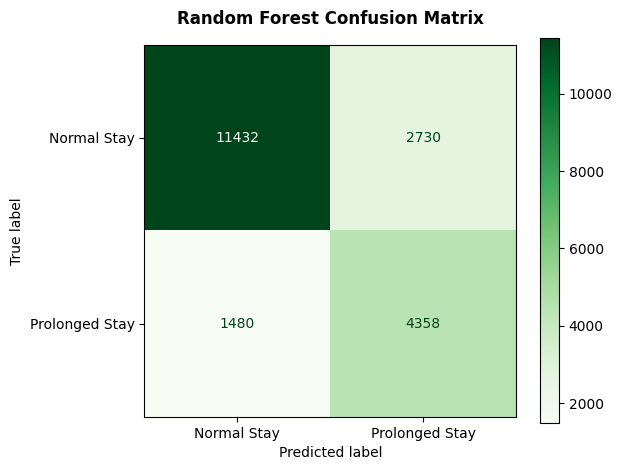

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test_rf, rf_preds)                                           # Calculating raw matrix counts using your active Random Forest variables

disp_rf = ConfusionMatrixDisplay(                                                       # Configuring the display mapping matrix layers
    confusion_matrix=cm_rf,
    display_labels=['Normal Stay', 'Prolonged Stay']
)

fig, ax = plt.subplots(figsize=(6, 5))                                                  # Plotting the matrix with a matching green theme to represent the tree ensemble
disp_rf.plot(cmap=plt.cm.Greens, ax=ax, values_format='d')

plt.title("Random Forest Confusion Matrix", pad=15, fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()


## 3. Top 10 Features: **RANDOM FOREST:**





/tmp/ipykernel_2557/3051868349.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


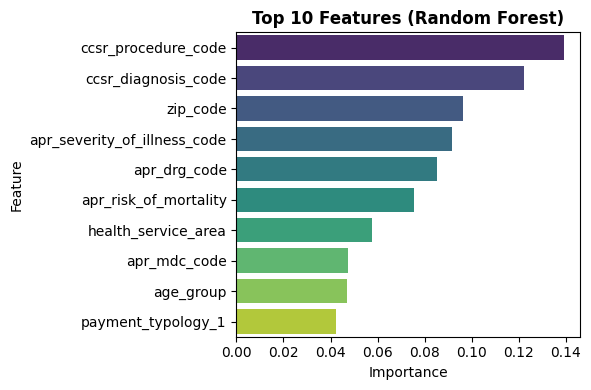

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

importance_df = pd.DataFrame({                                                   # Creating, sorting, and slicing the dataframe to the top 10 rows
    "Feature": X_train_rf.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(6, 4))                                                       # Plotting the bar chart
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Top 10 Features (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()



##**III) Boosting Tree Model**-->Gradient Boosting Classifier


## A.  Model Training: **GRADIENT BOOSTING CLASSIFIER**

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)                                              # Initializing the Gradient Boosting model

gb_model.fit(X_train_rf, y_train_rf);                                                              # Training the model (Note: Using X_test_rf in our evaluation suggests our training sets are named _rf)


## B.  Classification Report: **GRADIENT BOOSTING**

In [55]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

gb_probs = gb_model.predict_proba(X_test_rf)[:, 1]                                                 # Getting raw probability scores from our trained gradient boosting model

custom_threshold = 0.30                                                                            # Applying the identical 30%

gb_preds = (gb_probs >= custom_threshold).astype(int)

print("--- MODEL III: GRADIENT BOOSTING (BALANCED THRESHOLD) ---")                                 # Printing Evaluation Summaries
print(f"Accuracy Score: {accuracy_score(y_test_rf, gb_preds) * 100:.2f}%")
print(f"ROC-AUC Score : {roc_auc_score(y_test_rf, gb_probs):.4f}\n")

print("Classification Report:")
print(classification_report(y_test_rf, gb_preds, target_names=['Normal Stay', 'Prolonged Stay']))


--- MODEL III: GRADIENT BOOSTING (BALANCED THRESHOLD) ---
Accuracy Score: 77.34%
ROC-AUC Score : 0.8621

Classification Report:
                precision    recall  f1-score   support

   Normal Stay       0.90      0.77      0.83     14162
Prolonged Stay       0.58      0.78      0.67      5838

      accuracy                           0.77     20000
     macro avg       0.74      0.78      0.75     20000
  weighted avg       0.80      0.77      0.78     20000



## C. Confusion Matrix: **GRADIENT BOOSTING**


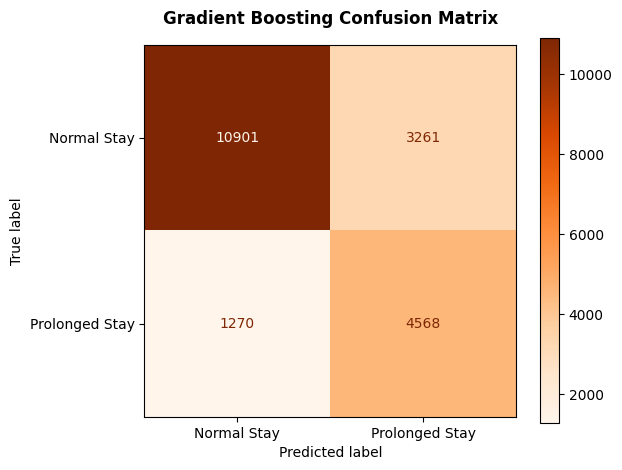

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_gb = confusion_matrix(y_test_rf, gb_preds)                                               # Calculating raw matrix counts using your active Gradient Boosting variables

disp_gb = ConfusionMatrixDisplay(                                                           # Configure the display mapping matrix layers
    confusion_matrix=cm_gb,
    display_labels=['Normal Stay', 'Prolonged Stay']
)

fig, ax = plt.subplots(figsize=(6, 5))                                                      # Plotting the matrix with an orange theme to represent the boosting ensemble
disp_gb.plot(cmap=plt.cm.Oranges, ax=ax, values_format='d')

plt.title("Gradient Boosting Confusion Matrix", pad=15, fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()


# **8. Comparative Performance Matrix Across:**
### - Linear (**LOGICAL REGRESION**) &
### - Ensemble Architectures (**RANDOM FOREST & GRADIENT BOOSTIN**G)
###   for ***"PLoS"*** Classification

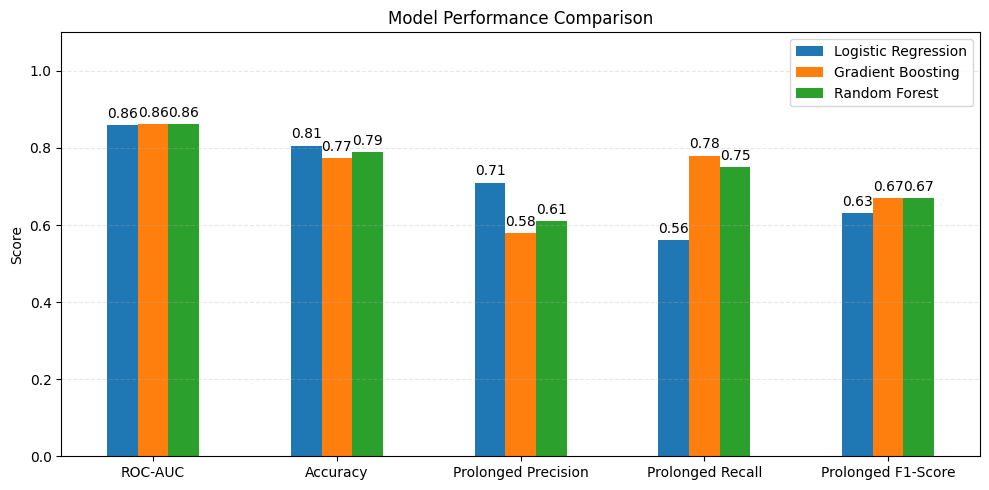

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = [                                                                     # Data variables

    "ROC-AUC",
    "Accuracy",
    "Prolonged Precision",
    "Prolonged Recall",
    "Prolonged F1-Score",
]
logistic_regression = [0.8599, 0.8061, 0.7100, 0.5600, 0.6300]
gradient_boosting = [0.8621, 0.7734, 0.5800, 0.7800, 0.6700]
random_forest = [0.8626, 0.7895, 0.6100, 0.7500, 0.6700]

df = pd.DataFrame(                                                              # Combined into a DataFrame
    {
        "Logistic Regression": logistic_regression,
        "Gradient Boosting": gradient_boosting,
        "Random Forest": random_forest,
    },
    index=metrics,
)

ax = df.plot(kind="bar", figsize=(10, 5), rot=0)                                # Chart(Bar) Plotted

for container in ax.containers:                                                 # Adding score labels automatically using a simple loop
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Model Performance Comparison")                                       # Basic layout adjustments
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## **Chart Highlights**
- **The Core Trade-off:** Logistic Regression maintains the highest overall Accuracy (0.81) and Prolonged Precision (0.71), but Gradient Boosting remains the top choice for capturing the highest volume of cases (Highest Recall at 0.78).
- **Best Balanced Model**: ***Random Forest*** proves to be the most optimal operational compromise, securing the highest overall ROC-AUC (0.86) and tied for the highest Prolonged F1-Score (0.67) while offering fewer false alarms than Gradient Boosting.
-** Performance Convergence:** Both ***Gradient Boosting*** and ***Random Forest*** converge perfectly on their final prediction balance, achieving an identical Prolonged F1-Score of 0.67.


# **9. Conclusion & Answers to Research Questions**:

- This project successfully developed an optimized machine learning pipeline using the 2024 NYS SPARCS dataset to answer our two core research objectives.
Research Question 1: Top 10 Predictive Features

### **Research Question**1: ***Top 10 Predictive Features (Adminstrative & Clinical) - Based on Top Model "RANDOM FOREST"***

- 1. ***ccsr_procedure_code***(The main surgery or procedure performed)
- 2. ***ccsr_diagnosis_code*** (Primary medical condition)
- 3. ***zip_code*** (The patient's regional location or socioeconomic factors)
- 4. ***apr_severity_of_illness_code*** (How severely ill the patient is)
- 5. ***apr_drg_code*** (All Patient Refined Diagnosis Related Group)
- 6. ***apr_risk_of_mortality*** (The patient's risk of dying)
- 7. ***health_service_are***a (The regional healthcare market or facility zone)
- 8. ***apr_mdc_code*** (The Major Diagnostic Category of the stay)
- 9. ***age_group*** (The patient's age bracket)
- 10. ***payment_typology_1*** (The primary insurance or payment provider type)

### **Research Question 2:** ***Final Model Selection -***
**The Random Forest Model:** is selected as the superior model for hospital deployment based on three clear wins:

- **Highest Predictive Power:** It scored the highest overall ability to separate normal vs. prolonged stays (ROC-AUC Score: 0.8626).
- **Fewer False Alarms:** It achieved a higher precision (0.61) than Gradient Boosting (0.58), meaning busy hospital staff will waste less time dealing with incorrect alerts.
- **Best Operational Balance:** It provides the strongest overall balance (Tied for Highest Prolonged F1-Score: 0.67), successfully capturing 75% of prolonged patient stays while maintaining greater accuracy and precision than Gradient Boosting.